# Exploración de datos crudos — ATFM

Primer vistazo al parquet exportado de OpenSky Network (`data/raw/`) antes de aplicar limpieza.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt

from src.config.settings import RAW_DIR, RAW_PARQUET_GLOB

archivo = sorted(RAW_DIR.glob(RAW_PARQUET_GLOB))[0]
df = pd.read_parquet(archivo)
df.shape

(97217, 19)

## Esquema y tipos de columna

In [2]:
df.dtypes

icao24                               object
firstSeen                           float64
estDepartureAirport                  object
lastSeen                              int32
estArrivalAirport                    object
callsign                             object
track                                object
serials                              object
estDepartureAirportHorizDistance    float64
estDepartureAirportVertDistance     float64
estArrivalAirportHorizDistance      float64
estArrivalAirportVertDistance       float64
departureAirportCandidatesCount       int32
arrivalAirportCandidatesCount         int32
otherDepartureAirportCandidates      object
otherArrivalAirportCandidates        object
airportOfDeparture                   object
airportOfDestination                 object
takeoffLandingInfo                   object
dtype: object

## Valores nulos por columna

In [3]:
nulos = df.isnull().sum().sort_values(ascending=False)
nulos[nulos > 0]

airportOfDestination                97217
airportOfDeparture                  97217
takeoffLandingInfo                  97217
otherDepartureAirportCandidates     23853
estDepartureAirportHorizDistance    23853
estDepartureAirport                 23853
estDepartureAirportVertDistance     23853
estArrivalAirportVertDistance       14525
otherArrivalAirportCandidates       14525
estArrivalAirport                   14525
estArrivalAirportHorizDistance      14525
firstSeen                             363
callsign                              102
dtype: int64

`airportOfDeparture` / `airportOfDestination` (aeropuerto *confirmado*) están
100% vacíos en este export: solo disponemos de los aeropuertos **estimados**
(`estDepartureAirport` / `estArrivalAirport`), inferidos por OpenSky a partir
de la posición del avión. Por eso el pipeline usa estos últimos y conserva
una métrica de confianza (`calidad_origen` / `calidad_destino`).

## Rango temporal cubierto

In [4]:
fechas = pd.to_datetime(df['firstSeen'].dropna(), unit='s')
print('Desde:', fechas.min())
print('Hasta:', fechas.max())
print('Vuelos totales:', len(df))
print('Aeropuertos de origen distintos:', df['estDepartureAirport'].nunique())
print('Aeropuertos de destino distintos:', df['estArrivalAirport'].nunique())

Desde: 2026-02-28 00:06:44
Hasta: 2026-03-01 23:38:06
Vuelos totales: 97217
Aeropuertos de origen distintos: 5339
Aeropuertos de destino distintos: 6811


## Distribución de la longitud del track (nº de puntos por vuelo)

In [5]:
longitudes_track = df['track'].apply(lambda t: len(t) if t is not None else 0)
longitudes_track.describe()

count    97217.000000
mean       192.868675
std        233.807688
min          0.000000
25%         74.000000
50%        141.000000
75%        228.000000
max       2400.000000
Name: track, dtype: float64

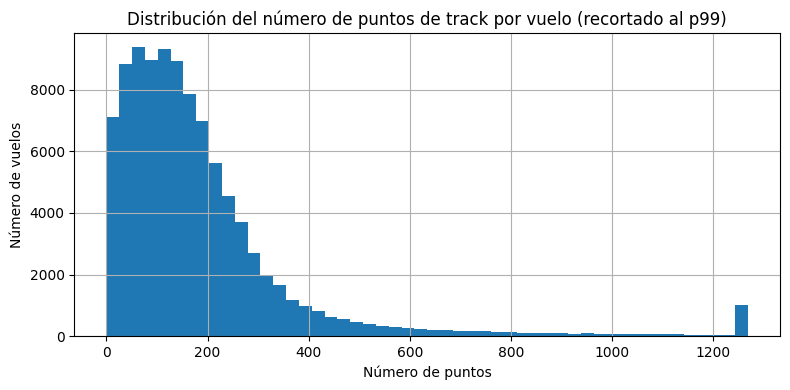

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
longitudes_track.clip(upper=longitudes_track.quantile(0.99)).hist(bins=50, ax=ax)
ax.set_title('Distribución del número de puntos de track por vuelo (recortado al p99)')
ax.set_xlabel('Número de puntos')
ax.set_ylabel('Número de vuelos')
plt.tight_layout()
plt.show()

## Ejemplo de una trayectoria individual

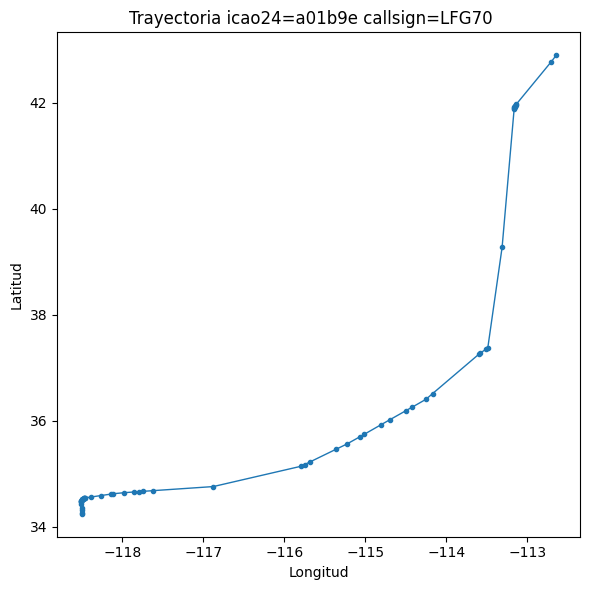

In [7]:
vuelo_ejemplo = df[longitudes_track > 50].iloc[0]
track = vuelo_ejemplo['track']
lats = [p['latitude'] for p in track]
lons = [p['longitude'] for p in track]

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(lons, lats, marker='.', linewidth=1)
ax.set_title(f"Trayectoria icao24={vuelo_ejemplo['icao24']} callsign={vuelo_ejemplo['callsign']}")
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
plt.tight_layout()
plt.show()